In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
file = '/mnt/nasvep/SCZ_CHINA/paula/derivatives/derivatives/tct_pipeline/sub-SCZ45/0_post_preprocessing/sub-SCZ45_dir-PA_traditional_filtered_bold.npz'
data = np.load(file)
bold = data['bold']

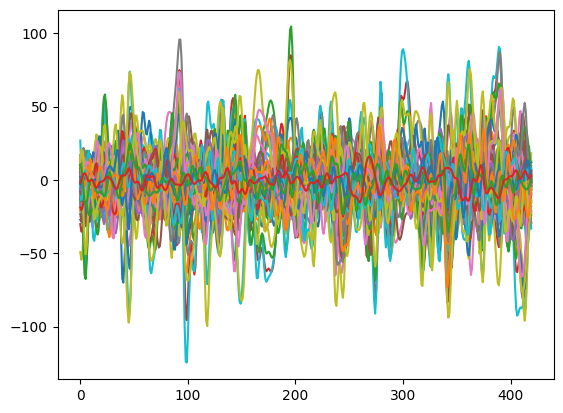

In [11]:
plt.plot(bold);

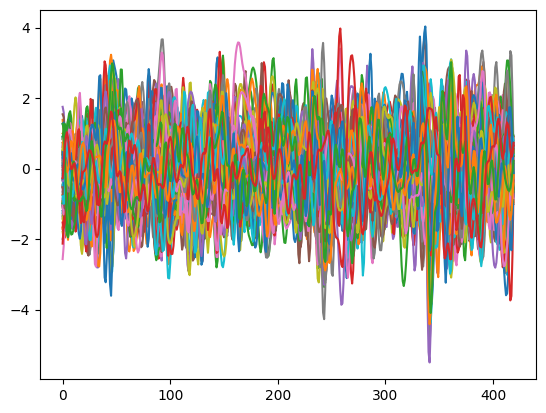

In [13]:
def standardize_bold(bold):
    mean = np.mean(bold, axis=0)
    std = np.std(bold, axis=0)
    standardized_bold = (bold - mean) / std
    return standardized_bold

standardized_bold = standardize_bold(bold)
plt.plot(standardized_bold);

In [14]:
import numpy as np
import scipy.stats as stats
from scipy.linalg import expm
import networkx as nx

# BOLD: (n_regions, n_timepoints)
bold = standardized_bold.T  # Transpose to (n_timepoints, n_regions)

# 1. FC matrix (Pearson correlation)
fc = np.corrcoef(bold)

# 2. Fisher z-transform (optional but recommended)
fc_z = np.arctanh(np.clip(fc, -0.999, 0.999))

# 3. Threshold for graph
thr = 0.3
A = (fc > thr).astype(int)
np.fill_diagonal(A, 0)

# 4. Graph
G = nx.from_numpy_array(A)

# Density
density = nx.density(G)

# Assortativity
assort = nx.degree_assortativity_coefficient(G)

# Communicability (weighted or z-scored FC)
C = expm(fc_z)

In [28]:
import numpy as np
from scipy.linalg import expm

def communicability(H):
    # node strength
    d = np.sum(H, axis=1)

    # normalization
    d_inv_sqrt = 1.0 / np.sqrt(d + 1e-12)
    D_inv_sqrt = np.diag(d_inv_sqrt)

    # normalized adjacency
    A = D_inv_sqrt @ H @ D_inv_sqrt

    # communicability matrix
    G = expm(A)

    return G

def mean_communicability(G, exclude_diag=True):
    if exclude_diag:
        idx = np.triu_indices_from(G, k=1)
        return np.mean(G[idx])
    return np.mean(G)

H = np.maximum(fc_z, 0)
C = communicability(H)

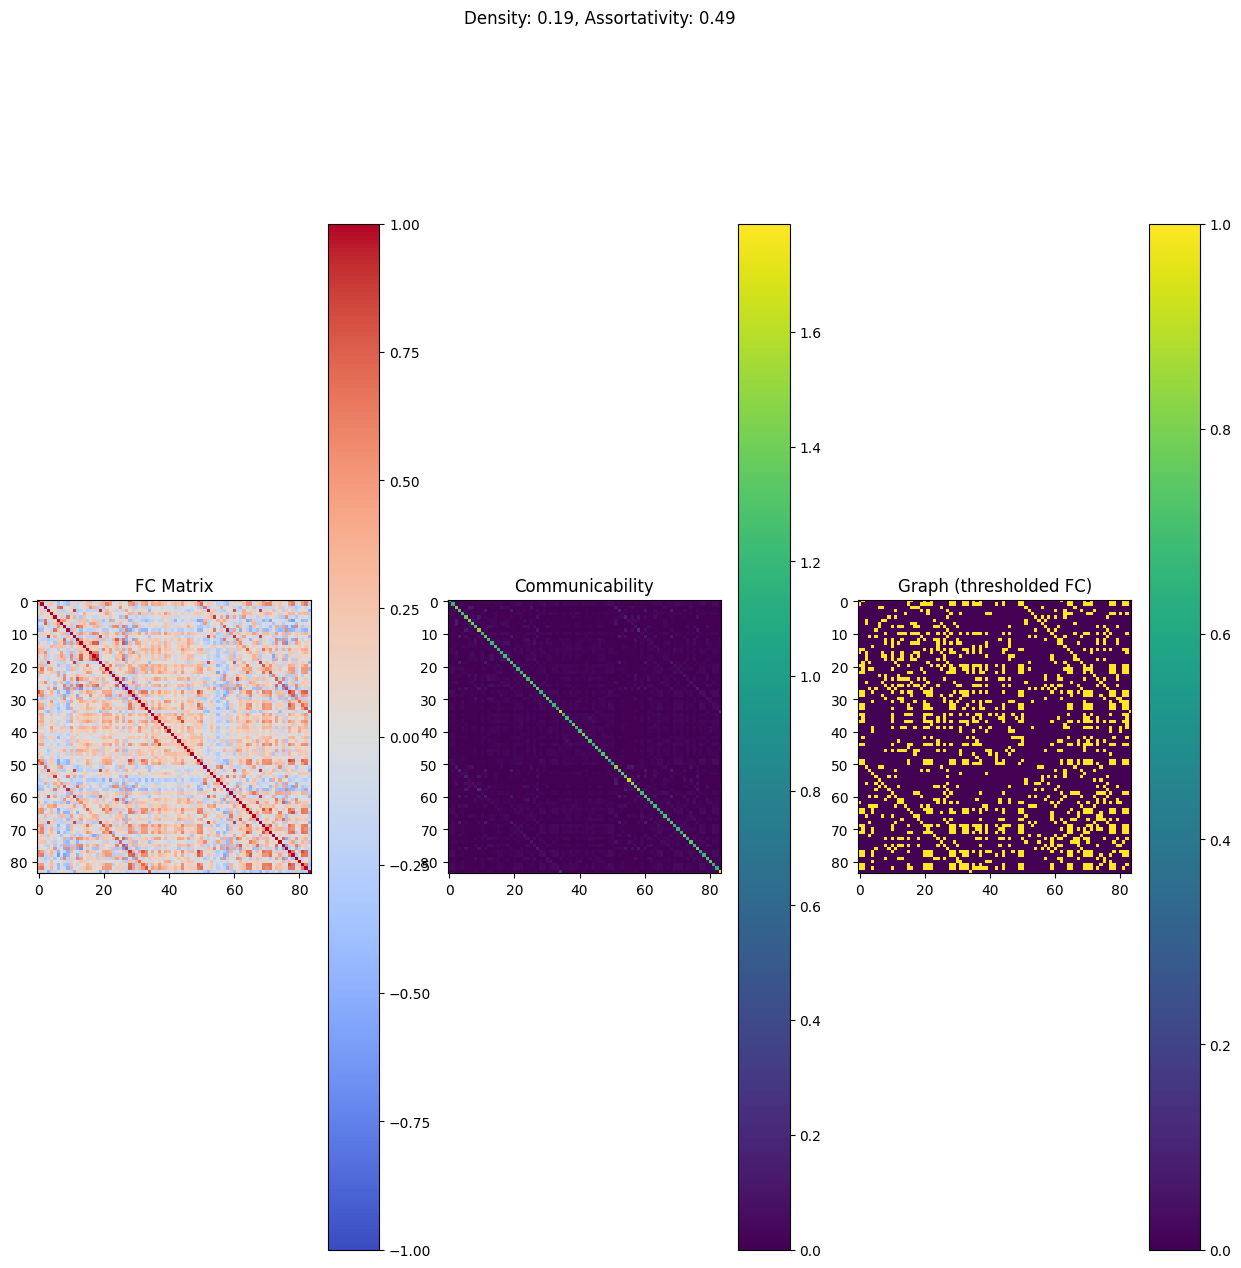

In [29]:
plt.figure(figsize=(15, 15))
plt.subplot(131)
plt.imshow(fc, vmin=-1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.title('FC Matrix')
plt.subplot(132)
plt.imshow(C, vmin=0, vmax=np.max(C), cmap='viridis')
plt.colorbar()
plt.title('Communicability')
plt.subplot(133)
plt.imshow(A)
plt.title('Graph (thresholded FC)')
plt.colorbar()
plt.suptitle(f'Density: {density:.2f}, Assortativity: {assort:.2f}')
plt.show()

In [16]:
assort

0.49076373075201535

In [17]:
density

0.19477911646586346